# Find relevant sig ids
From the genes create in the graph find all experiments where this gene is perturbed. For every such experiment map an unperturbed control sample. Additionlly store the L1000 mapping from gene symbol to gene id for the relvant genes

In **experiment_data** create:
- {pathway_name}_edge_index.pt
- {pathway_name}.topo
- {pathway_name}_gene_to_idx.pkl

In [1]:
import pandas as pd
from pathlib import Path
parent_dir = "data_phase1"
df_cell_info = pd.read_csv(f'{parent_dir}/cell_info.txt', sep='\t')     # Metadata for cell lines (the samples of the data matrices)
df_gene_info = pd.read_csv(f'{parent_dir}/gene_info.txt', sep='\t')     # Metadata for genes (the features of the data matrices)
df_inst_info = pd.read_csv(f'{parent_dir}/inst_info.txt', sep='\t')     # Metadata for L1000 experiments (the data matrices)
df_pert_info = pd.read_csv(f'{parent_dir}/pert_info.txt', sep='\t')     # Metadata for perturbations applied in L1000 experiments
df_sig_info = pd.read_csv(f'{parent_dir}/sig_info.txt', sep='\t')       # Metadata for level 5 profiles

print(f"{len(df_cell_info)} cell lines, {len(df_gene_info)} genes, {len(df_inst_info)} experiments, {len(df_pert_info)} perturbations, {len(df_sig_info)} signatures loaded.")

/tmp/ipykernel_3801849/3575807605.py:6: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_inst_info = pd.read_csv(f'{parent_dir}/inst_info.txt', sep='\t')     # Metadata for L1000 experiments (the data matrices)


98 cell lines, 12328 genes, 1319138 experiments, 51383 perturbations, 473647 signatures loaded.


/tmp/ipykernel_3801849/3575807605.py:8: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sig_info = pd.read_csv(f'{parent_dir}/sig_info.txt', sep='\t')       # Metadata for level 5 profiles


In [2]:
experiment_data_dir = "experiment_data"

In [3]:
# load pw_in_cancer_gene_to_idx.pkl to get all gene names in the pathway
import pickle
with open(f'{experiment_data_dir}/gene_to_idx.pkl', 'rb') as f:
    gene_to_idx = pickle.load(f)
gene_names = list(gene_to_idx.keys())
print(f"Loaded {len(gene_names)} gene names from {experiment_data_dir}/gene_to_idx.pkl")

# sanity check: make sure all gene names are in df_gene_info
for gene in gene_names:
    assert gene in df_gene_info['pr_gene_symbol'].values, f"Gene {gene} not found in df_gene_info"

Loaded 2655 gene names from experiment_data/gene_to_idx.pkl


In [4]:

df_sig_with_gene_info = df_sig_info.merge(df_gene_info, left_on='pert_iname', right_on='pr_gene_symbol', how='inner')
# select columns sig_id, pert_id, pr_gene_id, pr_gene_symbol, pert_type, cell_id
df_sig_with_gene_info = df_sig_with_gene_info[['sig_id', 'pert_id', 'pr_gene_id', 'pr_gene_symbol', 'pert_type', 'cell_id']]
df_sig_with_gene_info

,sig_id,pert_id,pr_gene_id,pr_gene_symbol,pert_type,cell_id
0,CGS001_A375_96H:A2M:1,CGS001-2,2,A2M,trt_sh.cgs,A375
1,CGS001_A375_96H:AARS:1,CGS001-16,16,AARS,trt_sh.cgs,A375
2,CGS001_A375_96H:AATF:1,CGS001-26574,26574,AATF,trt_sh.cgs,A375
3,CGS001_A375_96H:ABAT:1,CGS001-18,18,ABAT,trt_sh.cgs,A375
4,CGS001_A375_96H:ABCA1:1,CGS001-19,19,ABCA1,trt_sh.cgs,A375
...,...,...,...,...,...,...
193497,TAK004_U2OS_96H:TRCN0000370007:1,TRCN0000370007,25937,WWTR1,trt_sh,U2OS
193498,TAK004_U2OS_96H:TRCN0000370678:1,TRCN0000370678,2887,GRB10,trt_sh,U2OS
193499,TAK004_U2OS_96H:TRCN0000370697:1,TRCN0000370697,2887,GRB10,trt_sh,U2OS
193500,TAK004_U2OS_96H:TRCN0000370751:1,TRCN0000370751,2887,GRB10,trt_sh,U2OS


In [5]:
# filter df_perturbed_genes to only include rows where pr_gene_symbol is in the list of gene symbols in the graph G
print(f"ℹ️ Filtering perturbed genes from {len(df_sig_with_gene_info)} to only those present in the pathway graph.")
df_perturbed_genes = df_sig_with_gene_info[df_sig_with_gene_info['pr_gene_symbol'].isin(gene_names)]
print(f"✅ Filtered perturbed genes to {len(df_perturbed_genes)} genes present in the pathway graph.")
# print pert types with their counts
pert_type_counts = df_perturbed_genes['pert_type'].value_counts()
print("ℹ️ Perturbation types in filtered perturbed genes:")
for pert_type, count in pert_type_counts.items():
    print(f" - {pert_type}: {count}")

ℹ️ Filtering perturbed genes from 193502 to only those present in the pathway graph.
✅ Filtered perturbed genes to 76679 genes present in the pathway graph.
ℹ️ Perturbation types in filtered perturbed genes:
 - trt_sh: 54552
 - trt_sh.cgs: 10954
 - trt_oe: 6401
 - trt_lig: 4772


In [6]:
# get unique values for cell_id
cell_lines = df_perturbed_genes['cell_id'].unique().tolist()
print(f"Found {len(cell_lines)} unique cell lines with perturbations.")

control_pert_types = ['ctl_untrt.cns', 'ctl_untrt', 'ctl_vehicle.cns', 'ctl_vehicle']
control_samples = []
for cell_line in cell_lines:
    df_cell = df_sig_info[df_sig_info['cell_id'] == cell_line]
    for pert_type in control_pert_types:
        df_control = df_cell[df_cell['pert_type'] == pert_type]
        if not df_control.empty:
            break
    if not df_control.empty:
        control_sample = df_control.iloc[0]['sig_id']
        pert_type_found = df_control.iloc[0]['pert_type']
        control_samples.append({'cell_id': cell_line, 'control_sample': control_sample, 'pert_type': pert_type_found})
    else:
        print(f"⚠️ No control sample found for cell line {cell_line} with {len(df_cell)} samples.")
df_control_samples = pd.DataFrame(control_samples)
print(f"✅ Created control samples dataframe with {len(df_control_samples)} entries.")
df_control_samples

Found 25 unique cell lines with perturbations.
✅ Created control samples dataframe with 25 entries.


,cell_id,control_sample,pert_type
0,A375,CNS001_A375_96H:UNTRT:-666,ctl_untrt.cns
1,A549,CNS001_A549_96H:UNTRT:-666,ctl_untrt.cns
2,ASC,CNS001_ASC_96H:UNTRT:-666,ctl_untrt.cns
3,HA1E,CNS001_HA1E_96H:UNTRT:-666,ctl_untrt.cns
4,HCC515,CNS001_HCC515_96H:UNTRT:-666,ctl_untrt.cns
5,HEK293T,CNS001_HEK293T_48H:UNTRT:-666,ctl_untrt.cns
6,HEKTE,CNS001_HEKTE_96H:UNTRT:-666,ctl_untrt.cns
7,HEPG2,CNS001_HEPG2_96H:UNTRT:-666,ctl_untrt.cns
8,HT29,CNS001_HT29_96H:UNTRT:-666,ctl_untrt.cns
9,MCF7,CNS001_MCF7_144H:UNTRT:-666,ctl_untrt.cns


In [7]:
df_perturbation_pairs = df_perturbed_genes.merge(df_control_samples, on='cell_id', how='inner')

In [8]:
df_renamed_perturbation_pairs = df_perturbation_pairs[['control_sample', 'sig_id', 'pr_gene_symbol', 'pr_gene_id', 'cell_id', 'pert_type_x']].rename(
    columns={
        'control_sample': 'unperturbed_sig_id',
        'sig_id': 'perturbed_sig_id',
        'pr_gene_symbol': 'perturbed_gene',
        'pr_gene_id': 'perturbed_gene_id',
        'pert_type_x': 'perturbation_type',
        'cell_id': 'cell_line'
    }
)


In [9]:
REMOVE_NEAR_DUPLICATES = False
if REMOVE_NEAR_DUPLICATES:
    # group by perturbed_gene, perturbation_type and cell_line and count groups.
    # for each group, keep only one entry (the first one)
    df_renamed_perturbation_pairs = df_renamed_perturbation_pairs.groupby(['perturbed_gene', 'perturbation_type', 'cell_line']).first().reset_index()
    print(f"✅ Reduced to {len(df_renamed_perturbation_pairs)} unique perturbation pairs after grouping.")

In [10]:

out_path = Path(parent_dir) / 'perturbation_pairs.csv'
df_renamed_perturbation_pairs.to_csv(out_path, sep='\t', index=False)
print(f"✅ Wrote {len(df_renamed_perturbation_pairs)} perturbation pairs with perturbed_gene to {out_path}")

✅ Wrote 76679 perturbation pairs with perturbed_gene to data_phase1/perturbation_pairs.csv


In [11]:
df_perturbation_pairs

,sig_id,pert_id,pr_gene_id,pr_gene_symbol,pert_type_x,cell_id,control_sample,pert_type_y
0,CGS001_A375_96H:A2M:1,CGS001-2,2,A2M,trt_sh.cgs,A375,CNS001_A375_96H:UNTRT:-666,ctl_untrt.cns
1,CGS001_A375_96H:ABCA1:1,CGS001-19,19,ABCA1,trt_sh.cgs,A375,CNS001_A375_96H:UNTRT:-666,ctl_untrt.cns
2,CGS001_A375_96H:ABCB1:1,CGS001-5243,5243,ABCB1,trt_sh.cgs,A375,CNS001_A375_96H:UNTRT:-666,ctl_untrt.cns
3,CGS001_A375_96H:ABCF2:1,CGS001-10061,10061,ABCF2,trt_sh.cgs,A375,CNS001_A375_96H:UNTRT:-666,ctl_untrt.cns
4,CGS001_A375_96H:ABL1:1,CGS001-25,25,ABL1,trt_sh.cgs,A375,CNS001_A375_96H:UNTRT:-666,ctl_untrt.cns
...,...,...,...,...,...,...,...,...
76674,TAK004_U2OS_96H:TRCN0000370007:1,TRCN0000370007,25937,WWTR1,trt_sh,U2OS,TAK004_U2OS_96H:CMAP-000:1,ctl_untrt
76675,TAK004_U2OS_96H:TRCN0000370678:1,TRCN0000370678,2887,GRB10,trt_sh,U2OS,TAK004_U2OS_96H:CMAP-000:1,ctl_untrt
76676,TAK004_U2OS_96H:TRCN0000370697:1,TRCN0000370697,2887,GRB10,trt_sh,U2OS,TAK004_U2OS_96H:CMAP-000:1,ctl_untrt
76677,TAK004_U2OS_96H:TRCN0000370751:1,TRCN0000370751,2887,GRB10,trt_sh,U2OS,TAK004_U2OS_96H:CMAP-000:1,ctl_untrt


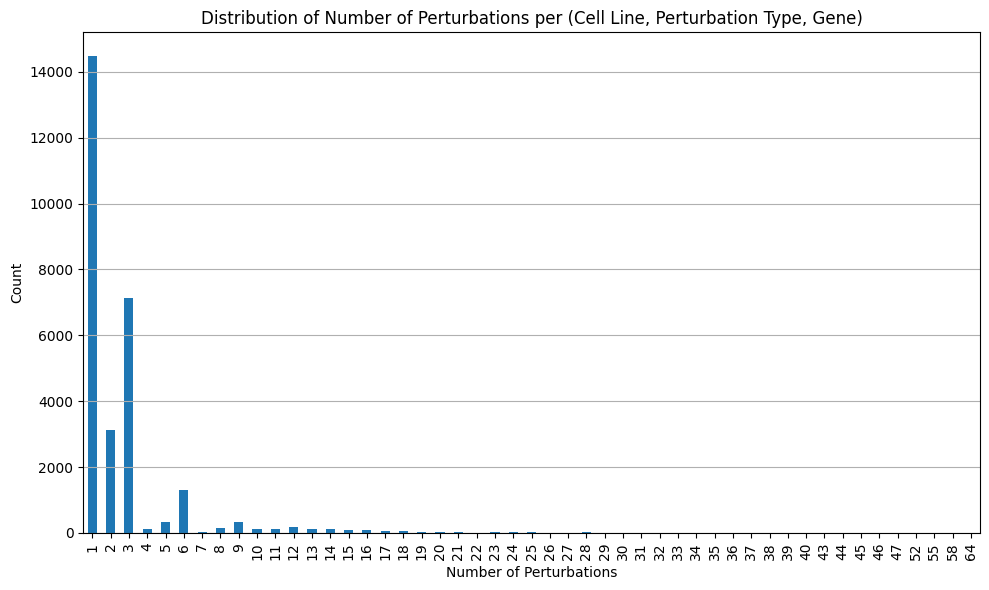

In [12]:
# in df_perturbation_pairs, group by cell_id, pert_type_x, perturbed_gene  and count number of perturbations
df_perturbation_counts = df_perturbation_pairs.groupby(['cell_id', 'pert_type_x', 'pr_gene_symbol']).size().reset_index(name='num_perturbations')
# sort by num_perturbations descending
df_perturbation_counts = df_perturbation_counts.sort_values(by='num_perturbations', ascending=False)
# plot value counts of num_perturbations as a bar plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df_perturbation_counts['num_perturbations'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Number of Perturbations')
plt.ylabel('Count')
plt.title('Distribution of Number of Perturbations per (Cell Line, Perturbation Type, Gene)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()